- Shuffle sequences 

In [1]:
import random

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import numpy as np
from matplotlib import pyplot as plt    

import optax
import equinox as eqx 
from jax import Array, numpy as jnp, random as jr, nn

from qwen import QwenModel, utils, generate, forward

In [3]:
def load_dataset(seq_len: int):
    loaded_data = np.load("data.npz")

    probs = [loaded_data["probs0"], loaded_data["probs1"], loaded_data["probs2"]]
    rewards = loaded_data["rewards"]
    actions = loaded_data["actions"]

    probs = [jnp.array(p) for p in probs]
    rewards = jnp.array(rewards)
    actions = jnp.array(actions)

    reward_ids = jnp.argmax(rewards, axis=-1)
    action_ids = jnp.argmax(actions, axis=-1)

    N = reward_ids.shape[0]
    split = int(0.9 * N)  

    train_probs = [p[:split] for p in probs]
    test_probs = [p[split:] for p in probs]

    train_rewards, test_rewards = reward_ids[:split], reward_ids[split:]
    train_actions, test_actions = action_ids[:split], action_ids[split:]

    B = train_rewards.shape[0] // seq_len  
    L = B * seq_len  

    train_probs = [p[:L].reshape(1, B, seq_len, -1) for p in train_probs]
    train_rewards = train_rewards[:L].reshape(1, B, seq_len)
    train_actions = train_actions[:L].reshape(1, B, seq_len)

    probs_inputs = [p[:, :, :-1, :] for p in train_probs]
    probs_targets = [p[:, :, 1:, :] for p in train_probs]

    reward_inputs, reward_targets = train_rewards[:, :, :-1], train_rewards[:, :, 1:]
    action_inputs, action_targets = train_actions[:, :, :-1], train_actions[:, :, 1:]

    return (
        probs_inputs[0], probs_inputs[1], probs_inputs[2],
        probs_targets[0], probs_targets[1], probs_targets[2],
        action_inputs, action_targets,
        reward_inputs, reward_targets,
        test_probs[0], test_probs[1], test_probs[2],
        test_actions, test_rewards,
    )


(1, 69, 127, 5)
(1, 69, 127, 16)
(1, 69, 127, 16)
(1, 69, 127, 5)
(1, 69, 127, 16)
(1, 69, 127, 16)
(1, 69, 127)
(1, 69, 127)
(1, 69, 127)
(1, 69, 127)
(984, 5)
(984, 16)
(984, 16)
(984,)
(984,)


In [3]:
def train_model(
    model,
    obj1_inputs,
    obj2_inputs,
    obj3_inputs,
    action_inputs,
    obj1_targets,
    obj2_targets,
    obj3_targets,
    callback,
    epochs,
    warmup_steps=2000,
):

    total_steps = epochs * len(obj1_inputs)

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=1e-4,
        warmup_steps=warmup_steps,
        decay_steps=total_steps,
        end_value=1e-6,
    )

    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(schedule, b1=0.9, b2=0.98, weight_decay=0.01),
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    def loss_fn(
        model, obj1_ids, obj2_ids, obj3_ids, action_ids, tgt_obj1, tgt_obj2, tgt_obj3
    ):
        logits = forward(model, obj1_ids, obj2_ids, obj3_ids, action_ids)
        logits_obj1, logits_obj2, logits_obj3 = jnp.split(logits, 3, axis=-1)

        loss_obj1 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj1, tgt_obj1
        )
        loss_obj2 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj2, tgt_obj2
        )
        loss_obj3 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj3, tgt_obj3
        )

        return (loss_obj1 + loss_obj2 + loss_obj3).mean()

    @eqx.filter_jit
    def step(
        model,
        opt_state,
        obj1_ids,
        obj2_ids,
        obj3_ids,
        action_ids,
        tgt_obj1,
        tgt_obj2,
        tgt_obj3,
    ):
        loss, grads = eqx.filter_value_and_grad(loss_fn)(
            model,
            obj1_ids,
            obj2_ids,
            obj3_ids,
            action_ids,
            tgt_obj1,
            tgt_obj2,
            tgt_obj3,
        )
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    for epoch in range(epochs):
        total_loss = 0.0

        for (
            batch_obj1,
            batch_obj2,
            batch_obj3,
            batch_action,
            batch_tgt1,
            batch_tgt2,
            batch_tgt3,
        ) in zip(
            obj1_inputs,
            obj2_inputs,
            obj3_inputs,
            action_inputs,
            obj1_targets,
            obj2_targets,
            obj3_targets,
        ):
            model, opt_state, loss = step(
                model,
                opt_state,
                batch_obj1,
                batch_obj2,
                batch_obj3,
                batch_action,
                batch_tgt1,
                batch_tgt2,
                batch_tgt3,
            )
            total_loss = total_loss + loss

        if epoch % 100 == 0:
            callback(model, total_loss / len(obj1_inputs))

    return model


def evaluate(
    model, test_obj1, test_obj2, test_obj3, test_actions, context_len=64, max_tokens=64
):
    start = random.randint(0, test_obj1.shape[0] - max_tokens - context_len)

    true_obj1_seq = test_obj1[start : start + context_len + max_tokens]
    true_obj2_seq = test_obj2[start : start + context_len + max_tokens]
    true_obj3_seq = test_obj3[start : start + context_len + max_tokens]
    true_action_seq = test_actions[start : start + context_len + max_tokens]

    context_obj1 = true_obj1_seq[:context_len]
    context_obj2 = true_obj2_seq[:context_len]
    context_obj3 = true_obj3_seq[:context_len]

    gen_obj1, gen_obj2, gen_obj3 = generate(
        model,
        obj1_tokens=jnp.array([context_obj1]),
        obj2_tokens=jnp.array([context_obj2]),
        obj3_tokens=jnp.array([context_obj3]),
        action_tokens=jnp.array([true_action_seq]),
        max_tokens=max_tokens,
    )

    gen_obj1, gen_obj2, gen_obj3 = (
        gen_obj1.squeeze(),
        gen_obj2.squeeze(),
        gen_obj3.squeeze(),
    )

    fig, axes = plt.subplots(3, 1, figsize=(6, 6))

    true_obj1_seq = true_obj1_seq[context_len:]
    true_obj2_seq = true_obj2_seq[context_len:]
    true_obj3_seq = true_obj3_seq[context_len:]

    gen_obj1 = gen_obj1[context_len:]
    gen_obj2 = gen_obj2[context_len:]
    gen_obj3 = gen_obj3[context_len:]

    axes[0].plot(range(len(gen_obj1)), gen_obj1, label="gen obj1")
    axes[0].plot(range(len(true_obj1_seq)), true_obj1_seq, label="true obj1")
    axes[0].set_title("Object 1")

    axes[1].plot(range(len(gen_obj2)), gen_obj2, label="gen obj2")
    axes[1].plot(range(len(true_obj2_seq)), true_obj2_seq, label="true obj2")
    axes[1].set_title("Object 2")

    axes[2].plot(range(len(gen_obj3)), gen_obj3, label="gen obj3")
    axes[2].plot(range(len(true_obj3_seq)), true_obj3_seq, label="true obj3")
    axes[2].legend()
    axes[2].set_title("Object 3")

    plt.tight_layout()
    plt.show()

9.419312


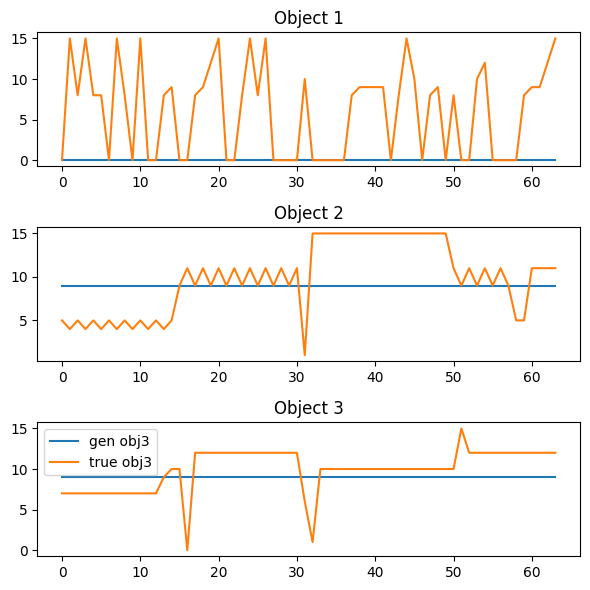

0.65052366


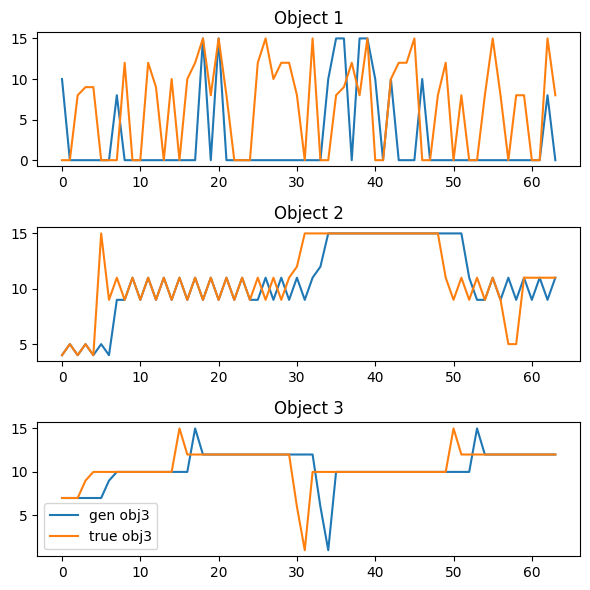

0.047192156


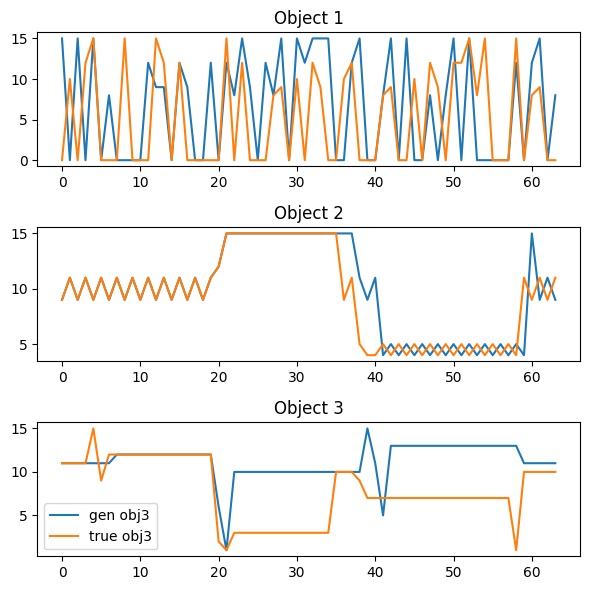

0.0063463165


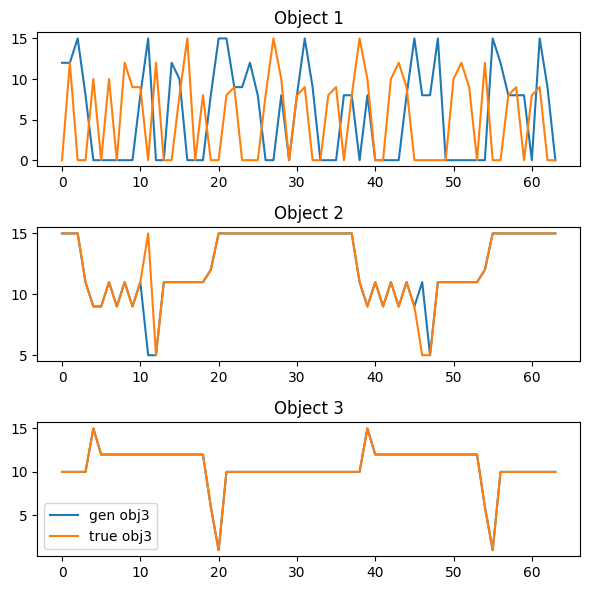

0.0049605845


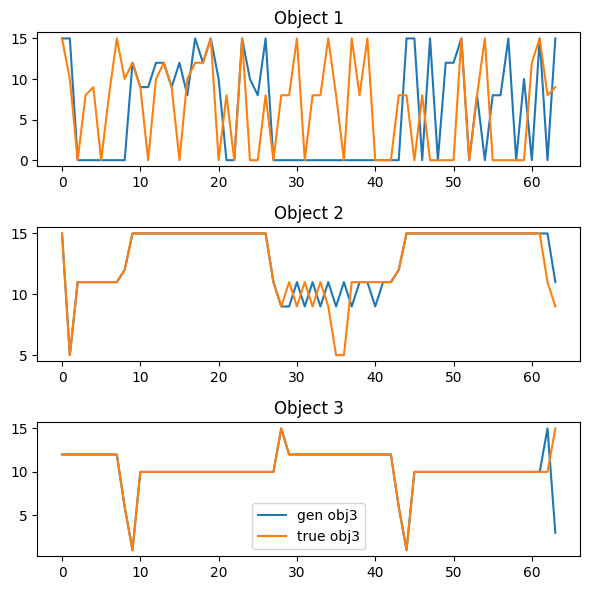

0.011113006


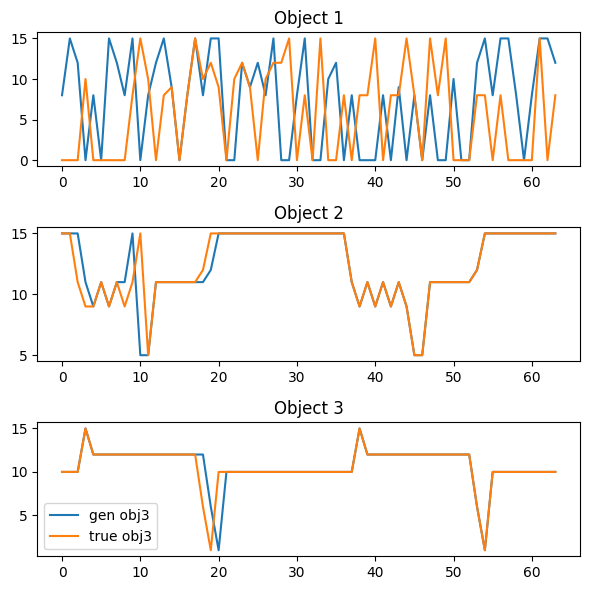

0.006081484


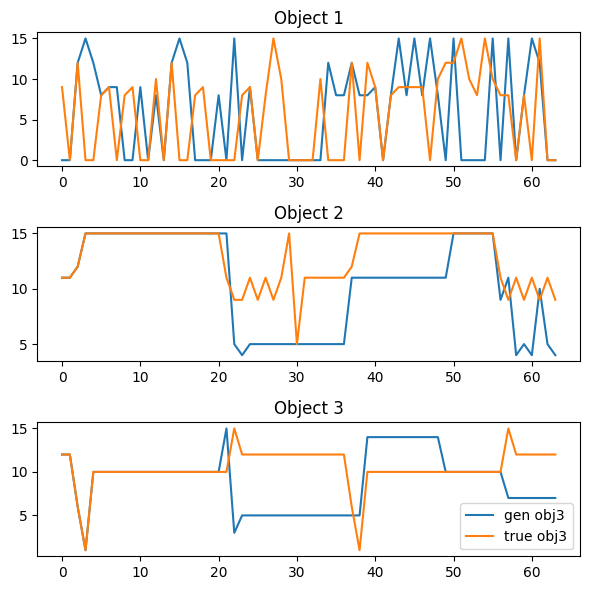

0.004619769


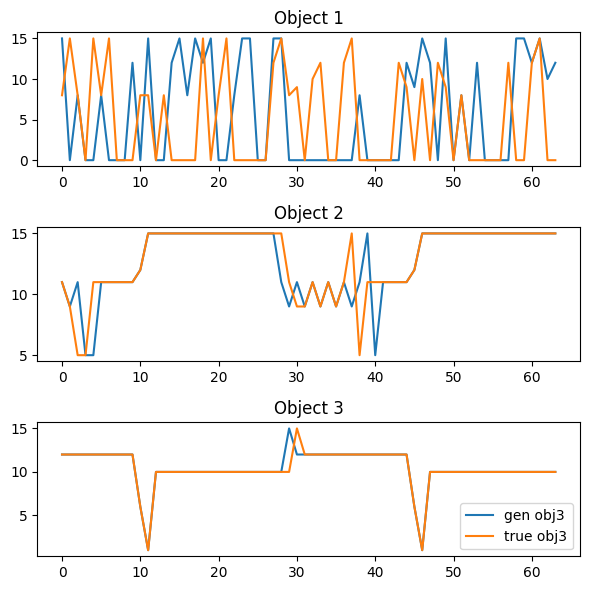

0.004542349


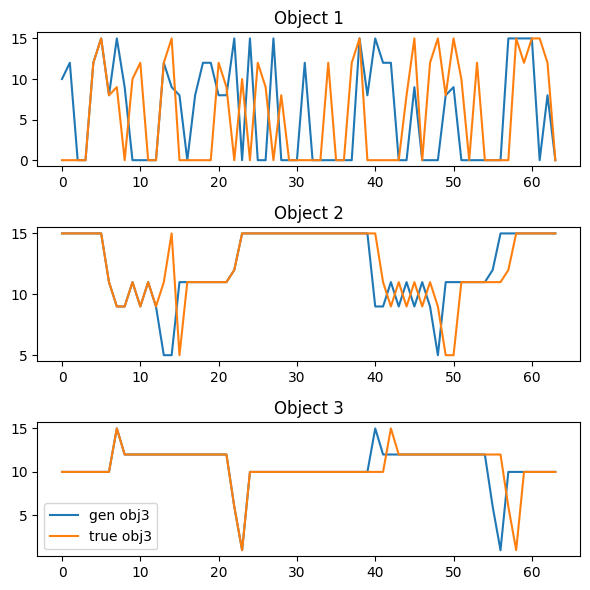

0.004508489


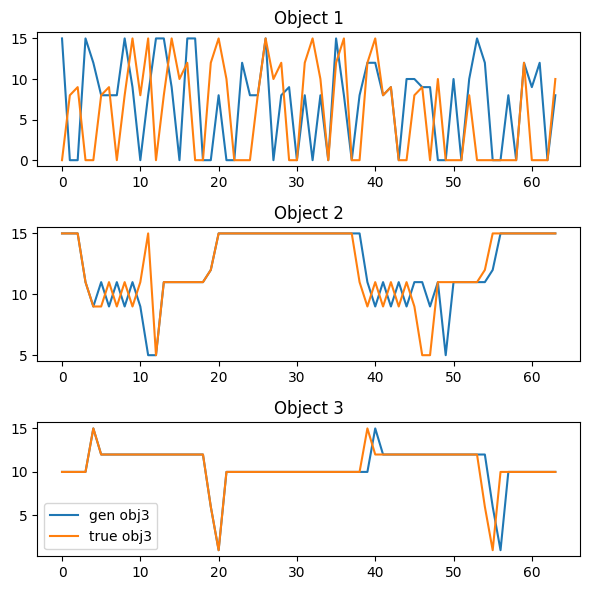

0.004486475


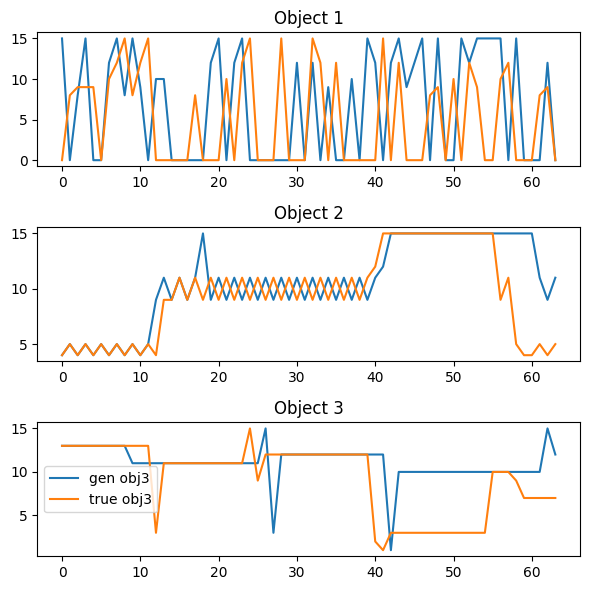

0.004467777


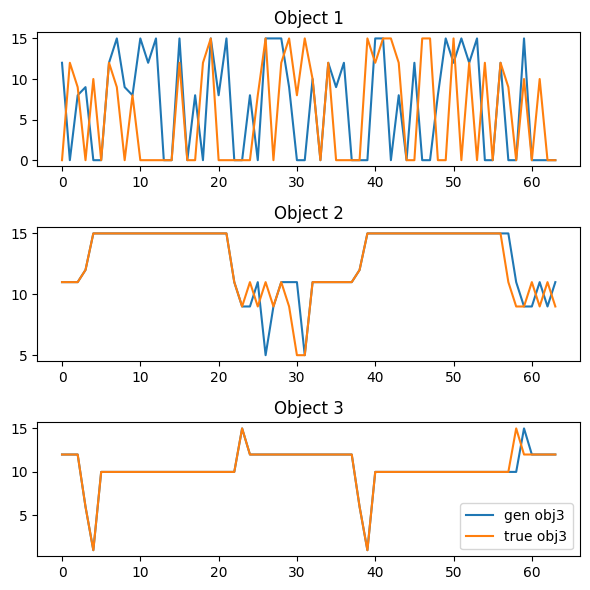

0.0044694208


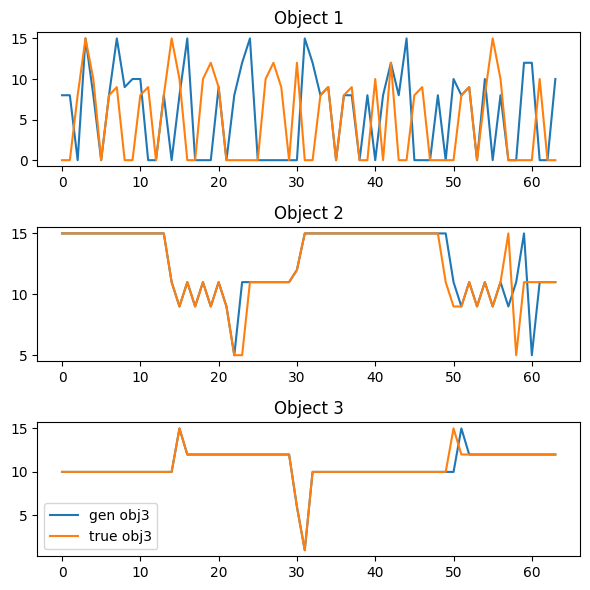

0.0044526393


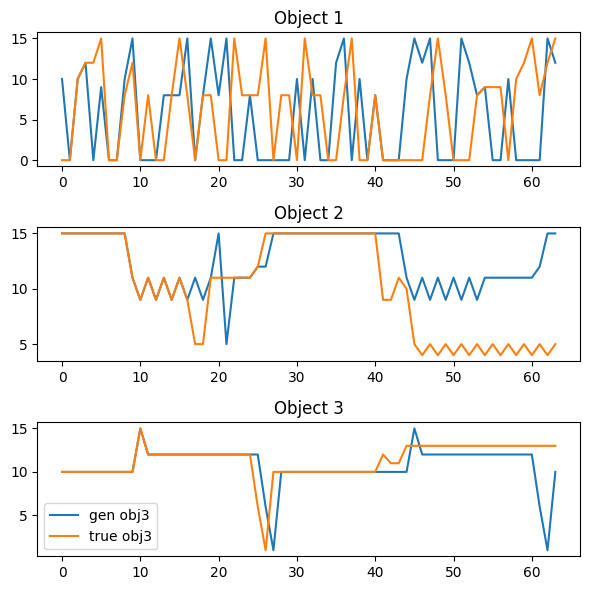

0.004446676


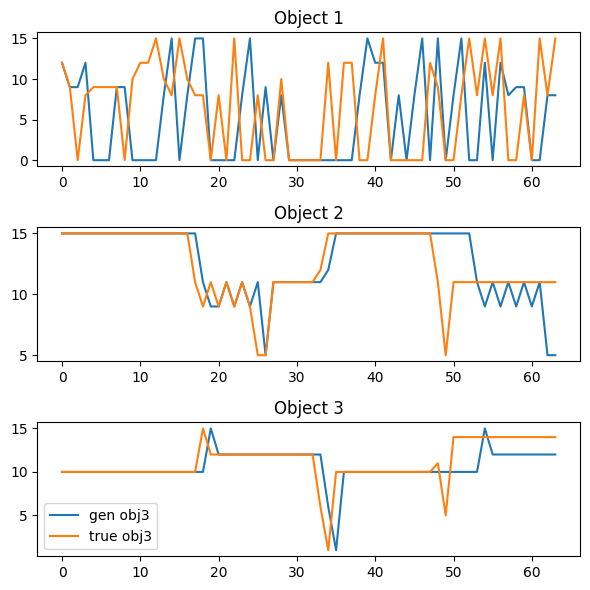

0.0044460567


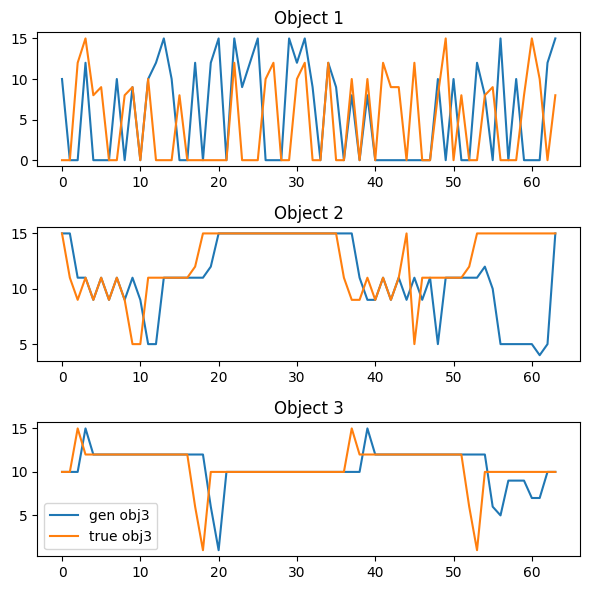

0.0044384515


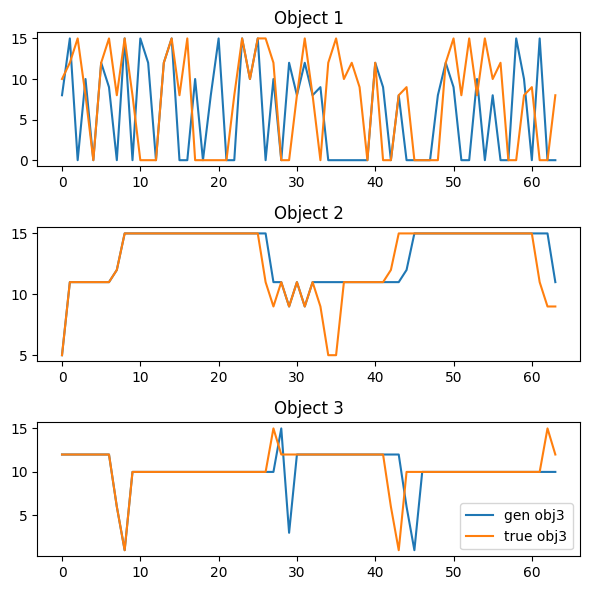

0.004437265


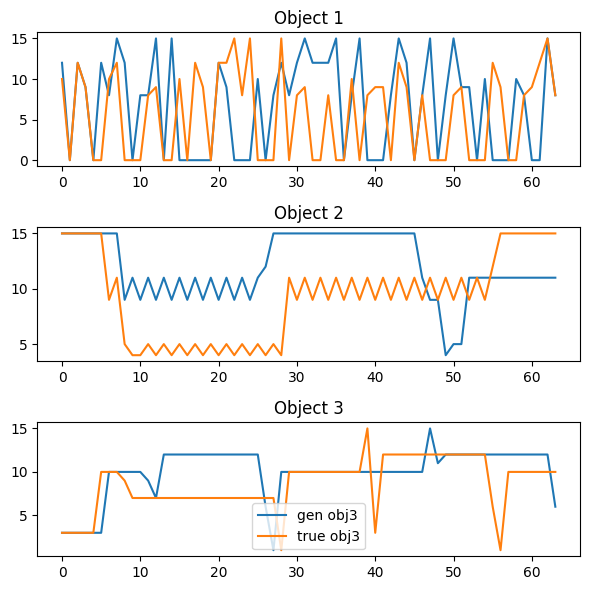

0.0044335737


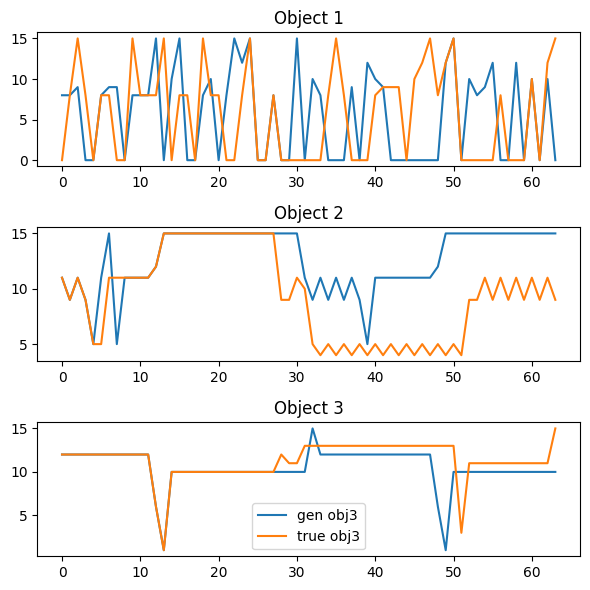

0.0044330647


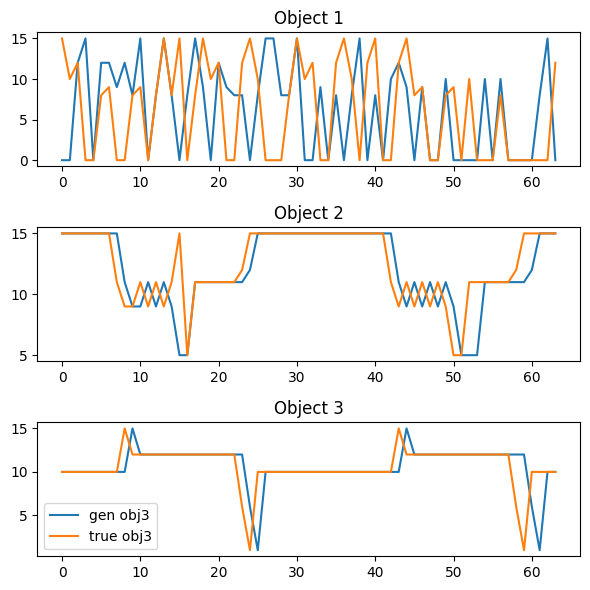

0.004431777


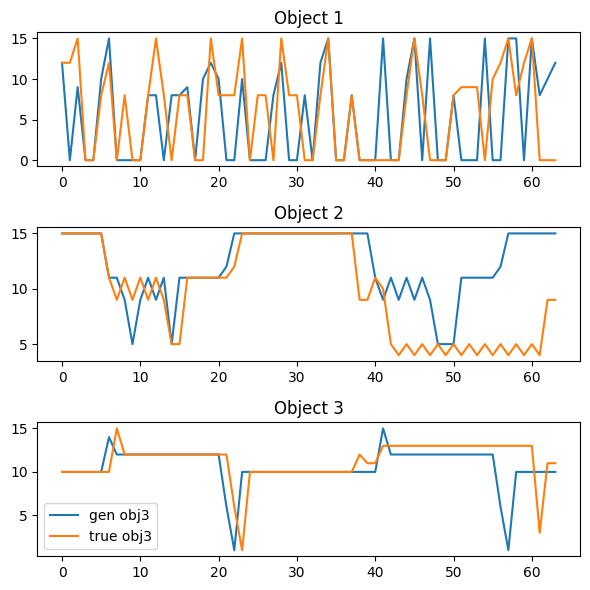

0.004431786


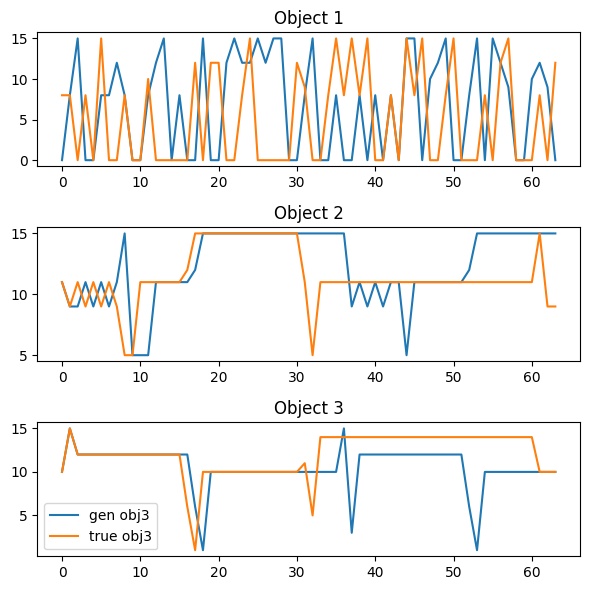

0.0044274023


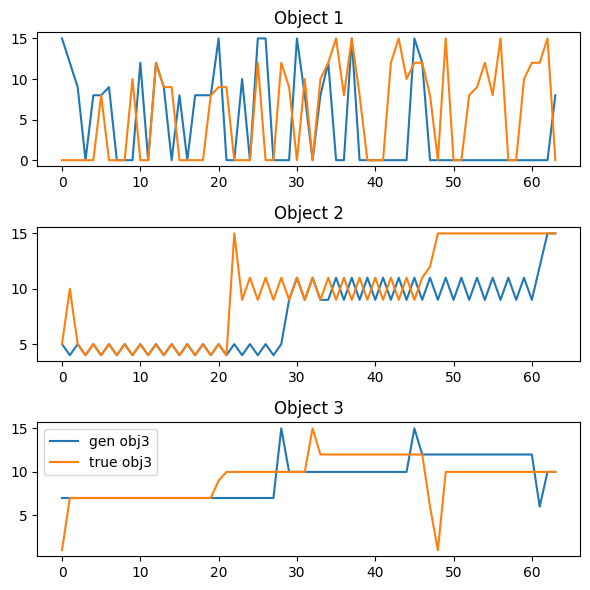

0.0044254195


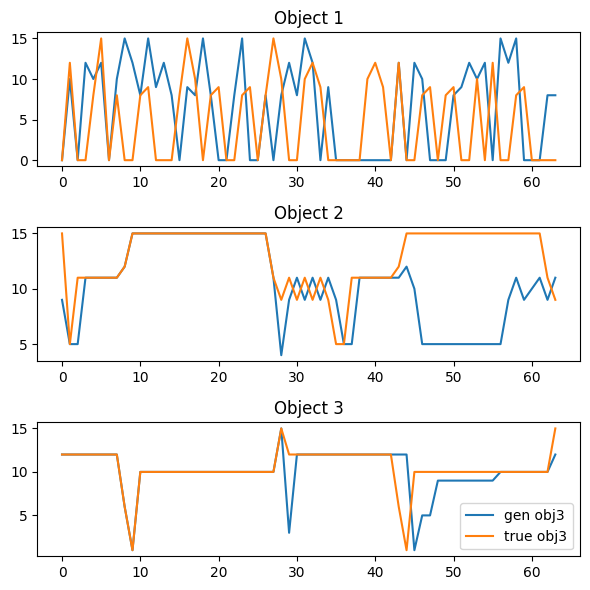

0.004424123


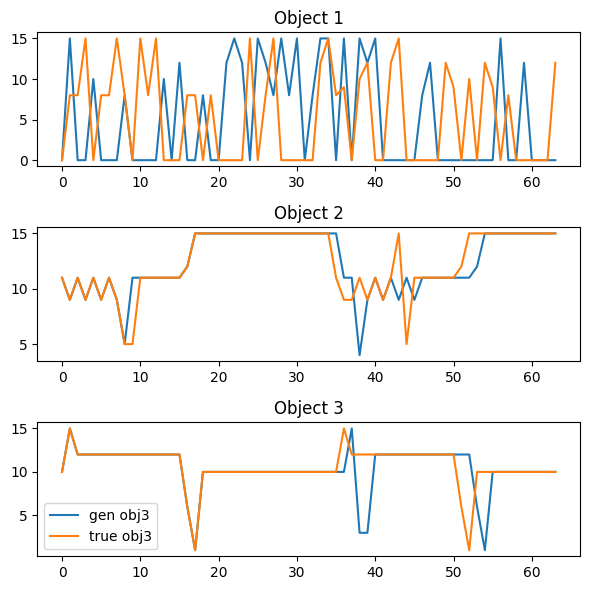

0.004424368


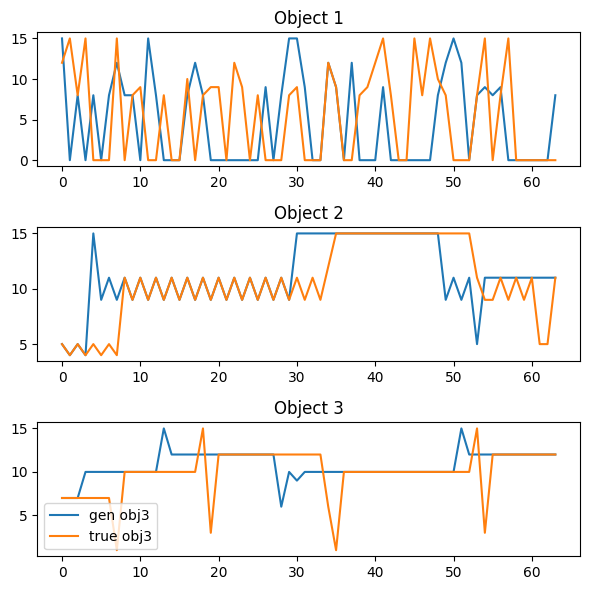

0.00442272


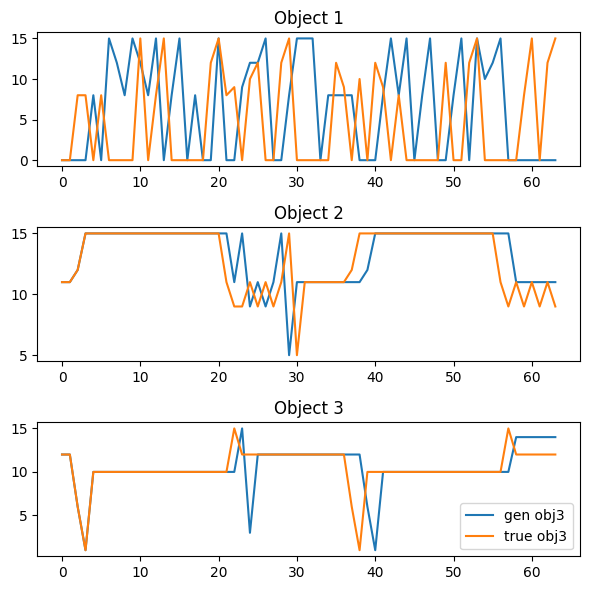

0.0044218013


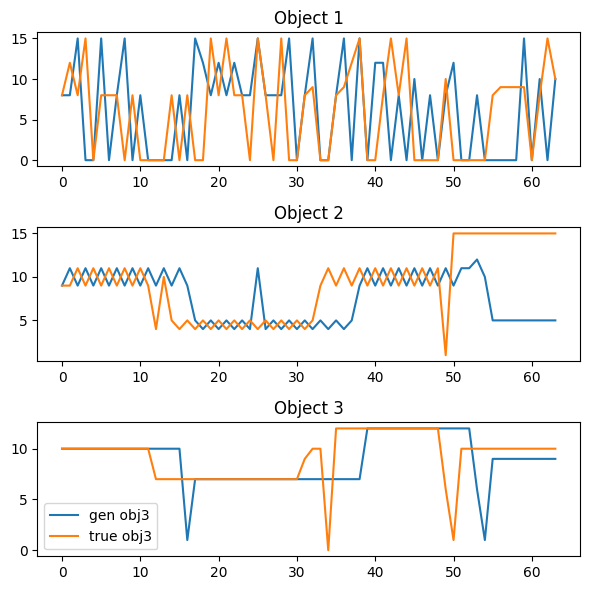

0.004420951


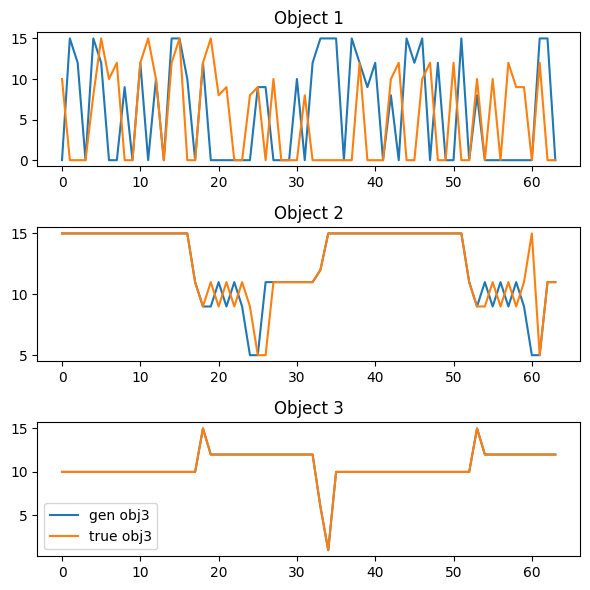

0.0044205706


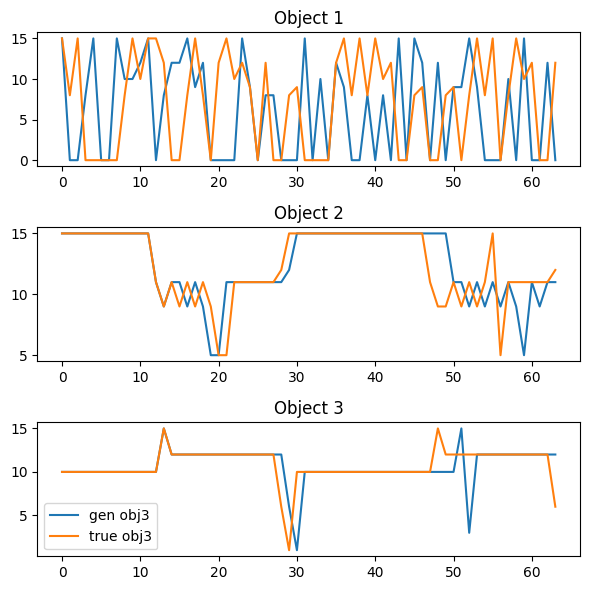

0.004419096


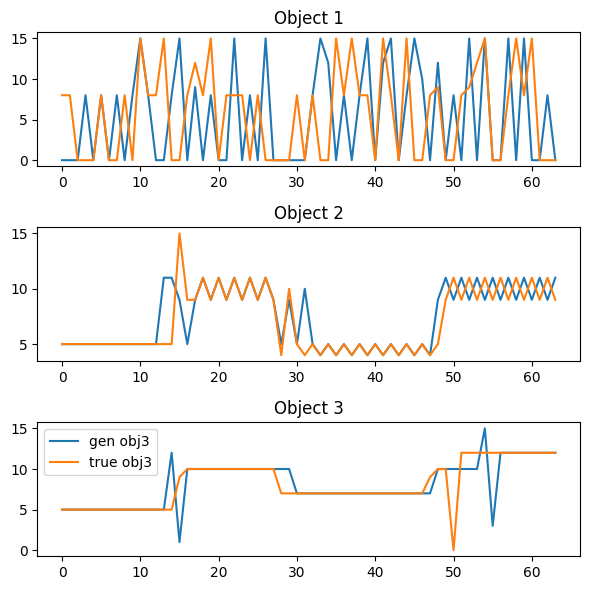

0.0055472273


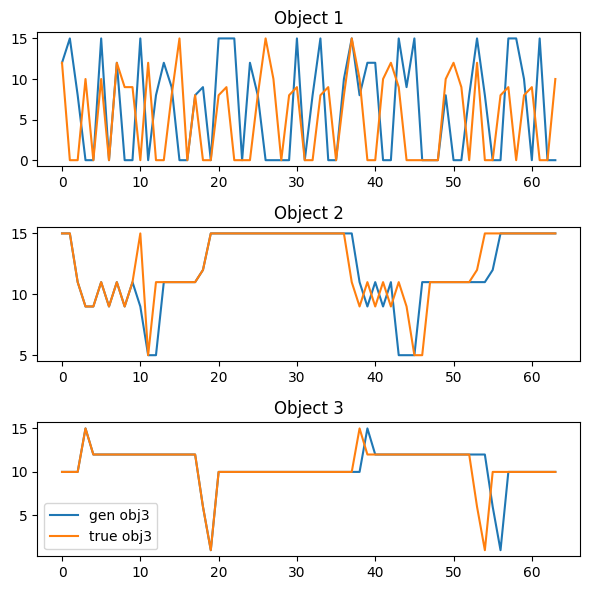

0.004891935


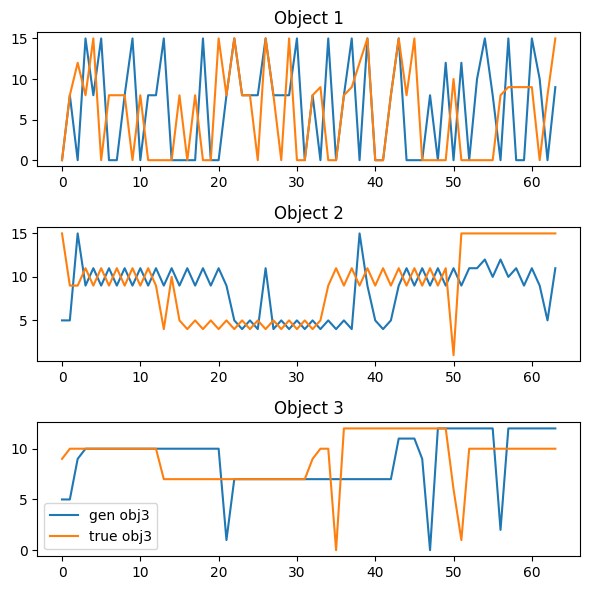

0.00444423


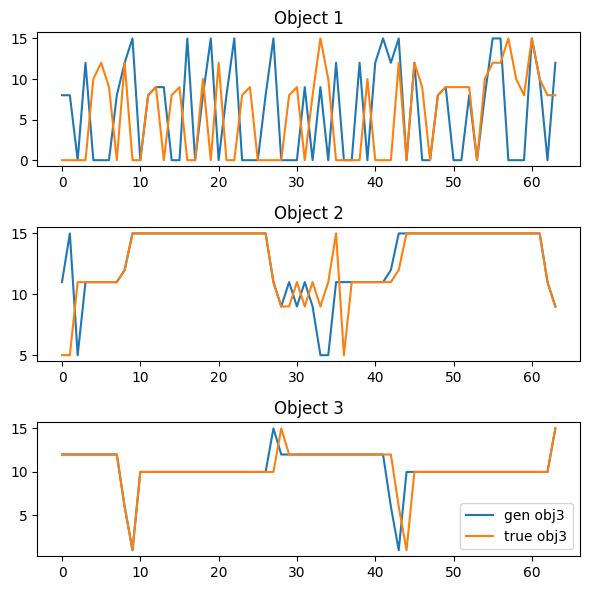

0.0044231685


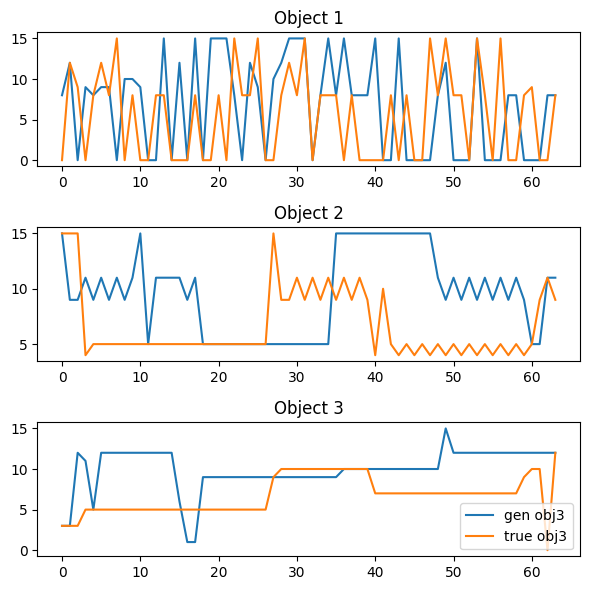

0.004421241


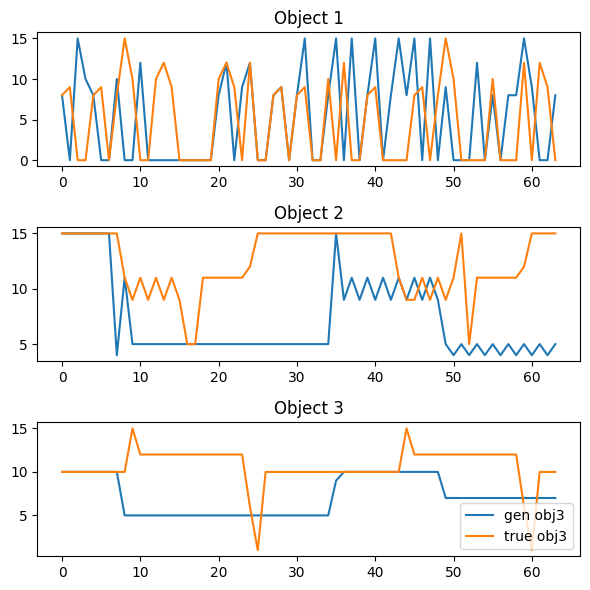

0.004419836


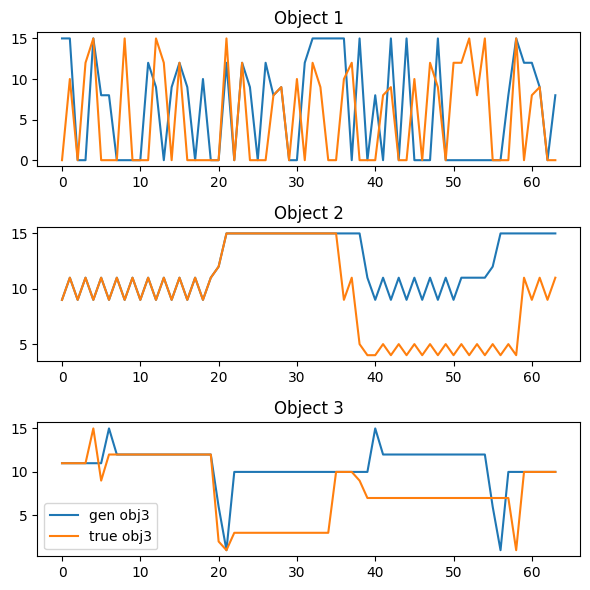

0.004420438


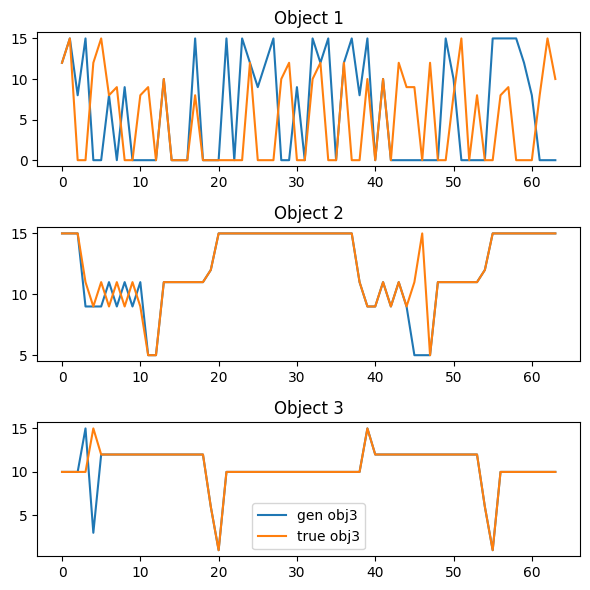

0.004417725


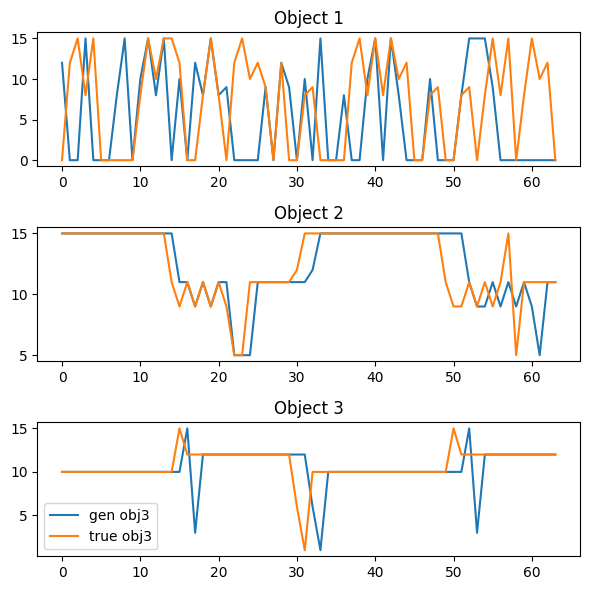

0.0044179494


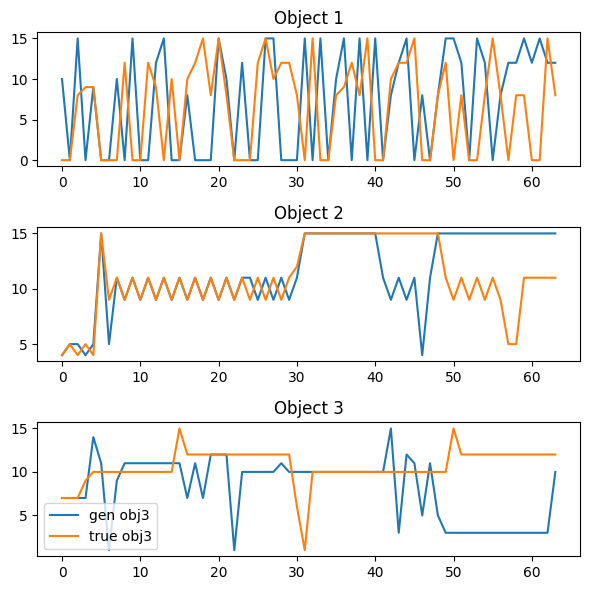

0.0044173193


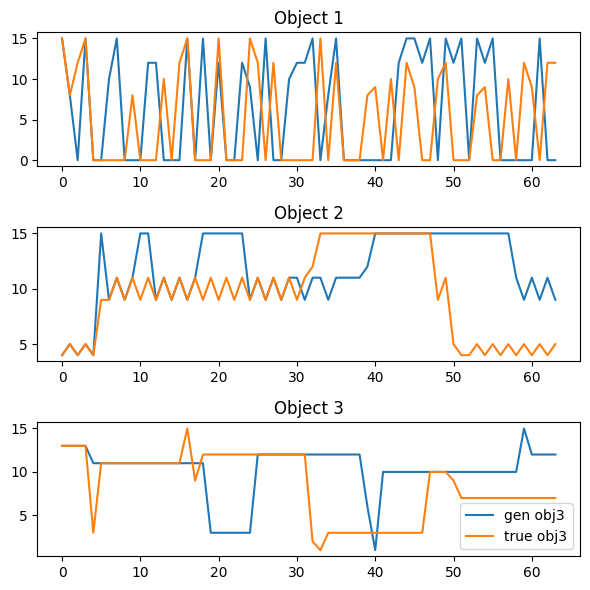

0.004419148


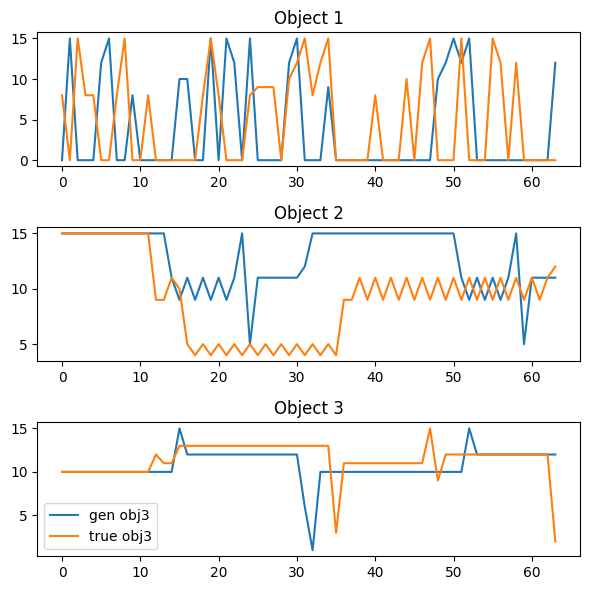

0.0044166464


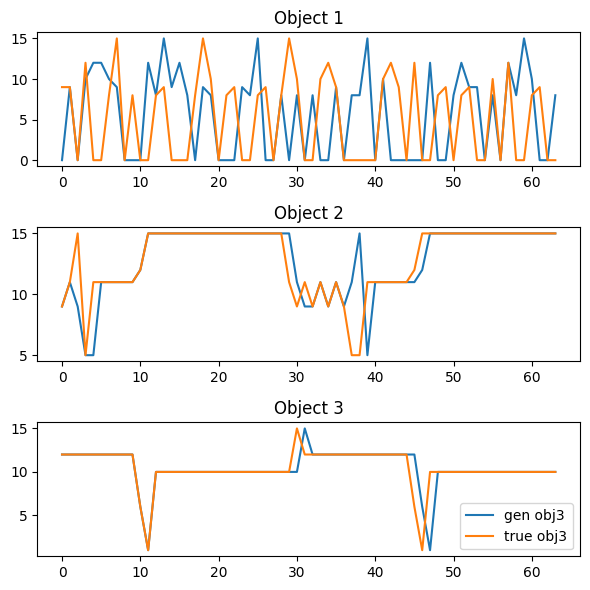

0.0044159014


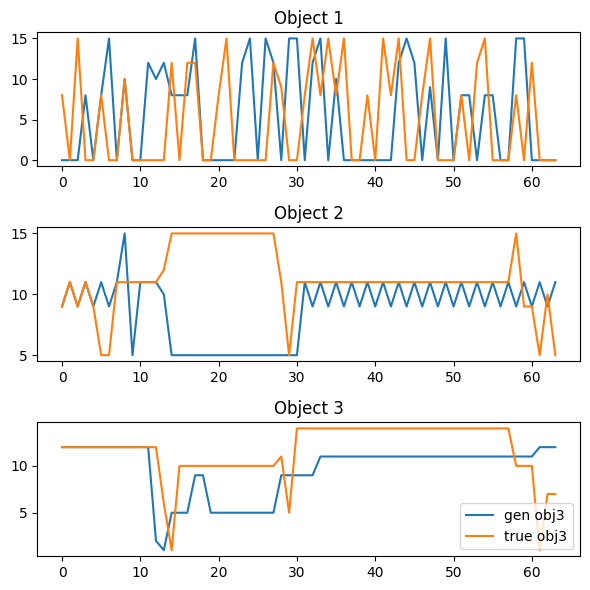

0.004416628


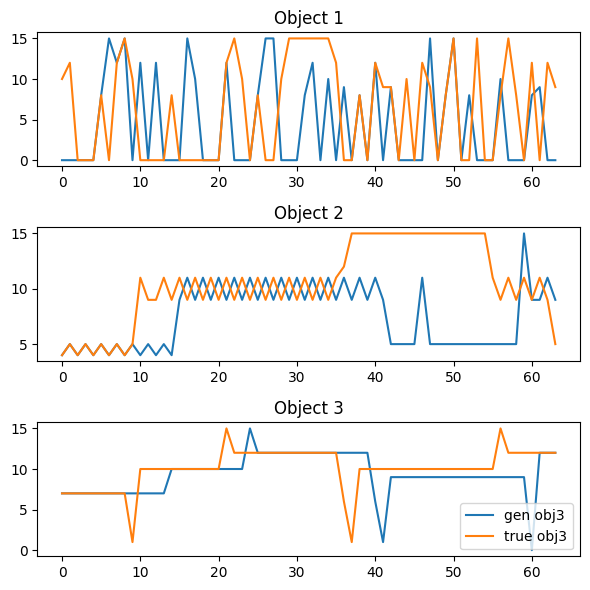

0.004416181


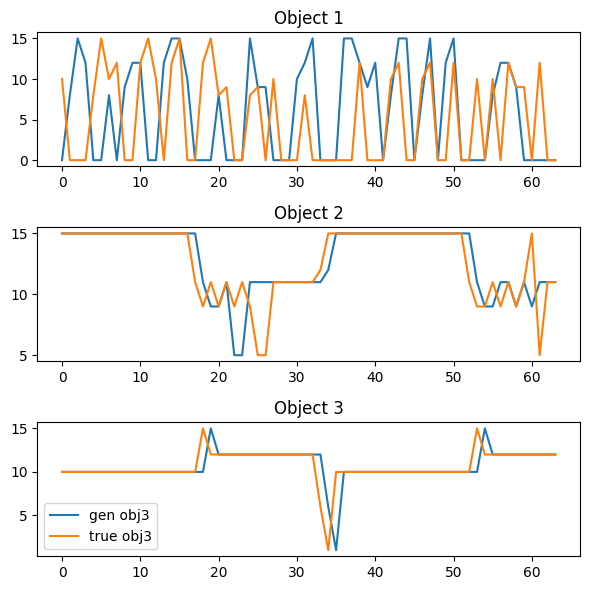

0.0044149305


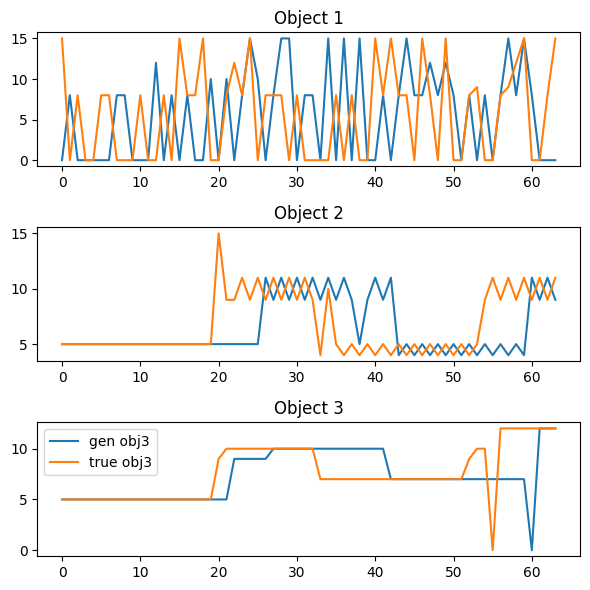

In [4]:
key = jr.PRNGKey(0)
model = utils.init(
    key,
    object1_size=16,
    object2_size=16,
    object3_size=16,
    action_size=3,
    embed_dim_per_field=32,
    hidden_size=256,
    num_layers=3,
    num_heads=4,
    num_key_value_heads=4,
    rope_theta=10000.0,
    rms_norm_eps=1e-6,
)

(
    obj1_inputs,
    obj2_inputs,
    obj3_inputs,
    obj1_targets,
    obj2_targets,
    obj3_targets,
    action_inputs,
    action_targets,
    reward_inputs,
    reward_targets,
    test_obj1,
    test_obj2,
    test_obj3,
    test_actions,
    test_rewards,
) = load_dataset(128)

def eval_callback(model, loss):
    print(loss)
    evaluate(model, test_obj1, test_obj2, test_obj3, test_actions, context_len=64, max_tokens=64)

model = train_model(model, obj1_inputs, obj2_inputs, obj3_inputs, action_inputs, obj1_targets, obj2_targets, obj3_targets, eval_callback, epochs=10000)